In [1]:
import numpy as np
import warnings
import xarray as xr
from dask.array.core import PerformanceWarning
from dask.diagnostics import ProgressBar
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Rectangle
from pyproj import Transformer

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from pystac_client import Client as pystac_client
from odc.stac import stac_load

warnings.filterwarnings("ignore", message="In a future version of xarray the default value for join.*", category=FutureWarning)
warnings.filterwarnings("ignore", message="Increasing number of chunks.*", category=PerformanceWarning)

# Approximate EPSG:3031 location for the Amundsen Sea sector / Thwaites-Pine Island area.
ROI_CENTER_XY_M = (-2_000_000.0, 800_000.0)
ROI_HALF_WIDTH_CELLS = 1000
CUBE_RES_M = 100

cx, cy = ROI_CENTER_XY_M
half = ROI_HALF_WIDTH_CELLS * CUBE_RES_M


antarctic_crs = ccrs.SouthPolarStereo(
    central_longitude=0,
    true_scale_latitude=-71,
)

In [2]:
to_lonlat = Transformer.from_crs("EPSG:3031", "EPSG:4326", always_xy=True)

corners_3031 = [
    (cx - half, cy - half),
    (cx - half, cy + half),
    (cx + half, cy - half),
    (cx + half, cy + half),
]

corners_lonlat = [to_lonlat.transform(x, y) for x, y in corners_3031]

bbox = [
    min(lon for lon, lat in corners_lonlat),
    min(lat for lon, lat in corners_lonlat),
    max(lon for lon, lat in corners_lonlat),
    max(lat for lon, lat in corners_lonlat),
]

bbox

[-71.56505117707799, -71.51944099302195, -64.6538240580533, -69.19453848840195]

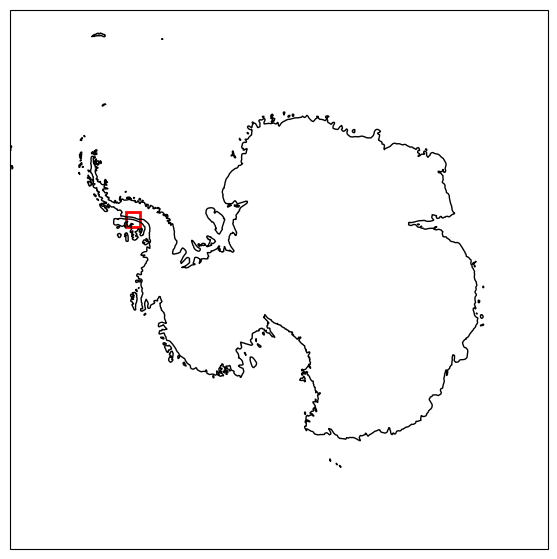

In [3]:
# Convert ROI center from meters to the appropriate scale and calculate half-width
cx, cy = ROI_CENTER_XY_M
half = ROI_HALF_WIDTH_CELLS * 100 

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -58], crs=ccrs.PlateCarree())
ax.coastlines()
ax.add_patch(Rectangle((cx - half, cy - half), 2 * half, 2 * half, fill=False, edgecolor="red", linewidth=2, transform=ax.projection))
plt.show()


In [4]:
cube_paths = [
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/icetemp.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/sec.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/antarctica-combined.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/icemask_composite.zarr/",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/ice_velocity.zarr",
]

ds = xr.open_mfdataset(cube_paths, engine="zarr", chunks={}, compat="no_conflicts")

x_index = int(np.abs(ds["x"].values - ROI_CENTER_XY_M[0]).argmin())
y_index = int(np.abs(ds["y"].values - ROI_CENTER_XY_M[1]).argmin())
x_slice = slice(x_index - ROI_HALF_WIDTH_CELLS, x_index + ROI_HALF_WIDTH_CELLS + 1)
y_slice = slice(y_index - ROI_HALF_WIDTH_CELLS, y_index + ROI_HALF_WIDTH_CELLS + 1)

ds = ds.isel(x=x_slice, y=y_slice).chunk({"x": -1, "y": -1})

ds


<xarray.Dataset> Size: 10GB
Dimensions:                                       (y: 2001, x: 2001, depth: 91,
                                                   time_period: 27, time: 48)
Coordinates:
  * y                                             (y) float32 8kB 7e+05 ... 9...
  * x                                             (x) float32 8kB -2.1e+06 .....
  * depth                                         (depth) int16 182B 0 ... 4500
  * time_period                                   (time_period) int64 216B 0 ...
  * time                                          (time) datetime64[ns] 384B ...
    spatial_ref                                   int64 8B 0
Data variables: (12/40)
    englacial_temp_profile_quality_flag           (y, x) float16 8MB dask.array<chunksize=(2001, 2001), meta=np.ndarray>
    englacial_temp_profile_tice                   (depth, y, x) float16 729MB dask.array<chunksize=(1, 2001, 2001), meta=np.ndarray>
    surface_elevation_change_basin_id             (y, x) float32 16MB dask.array<chunksize=(2001, 2001), meta=np.ndarray>
    surface_elevation_change_cell_end_times       (time_period, y, x) float32 432MB dask.array<chunksize=(1, 2001, 2001), meta=np.ndarray>
    surface_elevation_change_cell_start_times     (time_period, y, x) float32 432MB dask.array<chunksize=(1, 2001, 2001), meta=np.ndarray>
    surface_elevation_change_end_time             (time_period) float32 108B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                                            ...
    ice_sheet_surface_velocity_easting_stddev     (time, y, x) float32 769MB dask.array<chunksize=(1, 2001, 2001), meta=np.ndarray>
    ice_sheet_surface_velocity_magnitude          (time, y, x) float32 769MB dask.array<chunksize=(1, 2001, 2001), meta=np.ndarray>
    ice_sheet_surface_velocity_measurement_count  (time, y, x) float32 769MB dask.array<chunksize=(1, 2001, 2001), meta=np.ndarray>
    ice_sheet_surface_velocity_northing           (time, y, x) float32 769MB dask.array<chunksize=(1, 2001, 2001), meta=np.ndarray>
    ice_sheet_surface_velocity_northing_stddev    (time, y, x) float32 769MB dask.array<chunksize=(1, 2001, 2001), meta=np.ndarray>
    ice_sheet_surface_velocity_vertical           (time, y, x) float32 769MB dask.array<chunksize=(1, 2001, 2001), meta=np.ndarray>

In [5]:
# !jupyter nbconvert --to script "your_notebook.ipynb"

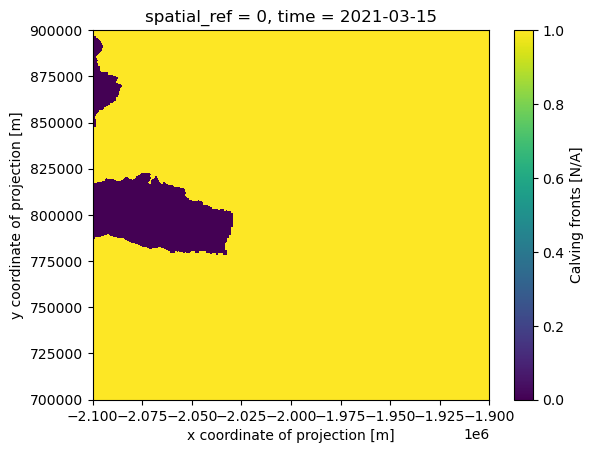

In [6]:
ds.calving_fronts.isel(time=-10).plot()

In [16]:
items[0]

<Item id=S2B_17CNU_20210320_0_L2A>

In [7]:
catalog = pystac_client.open("https://earth-search.aws.element84.com/v1")
chunk={} # <-- use dask
res=100 # 100m resolution

query1 = catalog.search(
    collections=["sentinel-2-l2a"], datetime="2021-03-01/2021-04-10", limit=100,
    bbox=bbox, query={"eo:cloud_cover": {"lt": 50}}
)

items = list(query1.items())
len(items)

113

In [8]:
from IPython.display import Image, display
import ipywidgets as widgets

def show(i):
    item = items[i]
    print(i, item.id, item.properties.get("eo:cloud_cover"))
    display(Image(url=item.assets["thumbnail"].href, width=600))

widgets.interact(
    show,
    i=widgets.IntSlider(0, 0, len(items) - 1, continuous_update=False),
)

interactive(children=(IntSlider(value=0, continuous_update=False, description='i', max=112), Output()), _dom_c…

<function __main__.show(i)>

In [9]:
sen2_ds = stac_load(
    items,
    bands=("red", "green", "blue", 'scl'),
    resolution=100,
    bbox=bbox,
    chunks={},
)

with ProgressBar():
    sen2_ds = sen2_ds.load()

[                                        ] | 1% Completed | 2.30 s ms

/opt/miniconda3/envs/pangeo/lib/python3.13/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/opt/miniconda3/envs/pangeo/lib/python3.13/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


[#                                       ] | 3% Completed | 55.06 s


KeyboardInterrupt: 

In [ ]:
bad_scl = [0, 1, 3, 8, 9, 10]
clear = ~sen2_ds["scl"].isin(bad_scl)

rgb = sen2_ds[["red", "green", "blue"]].where(clear)

rgb

<xarray.Dataset> Size: 4GB
Dimensions:      (time: 43, y: 2628, x: 2739)
Coordinates:
  * time         (time) datetime64[ns] 344B 2021-03-03T13:52:10.422000 ... 20...
  * y            (y) float64 21kB 2.322e+06 2.322e+06 ... 2.059e+06 2.059e+06
  * x            (x) float64 22kB 3.984e+05 3.984e+05 ... 6.72e+05 6.722e+05
    spatial_ref  int32 4B 32719
Data variables:
    red          (time, y, x) float32 1GB nan nan nan nan ... nan nan nan nan
    green        (time, y, x) float32 1GB nan nan nan nan ... nan nan nan nan
    blue         (time, y, x) float32 1GB nan nan nan nan ... nan nan nan nan

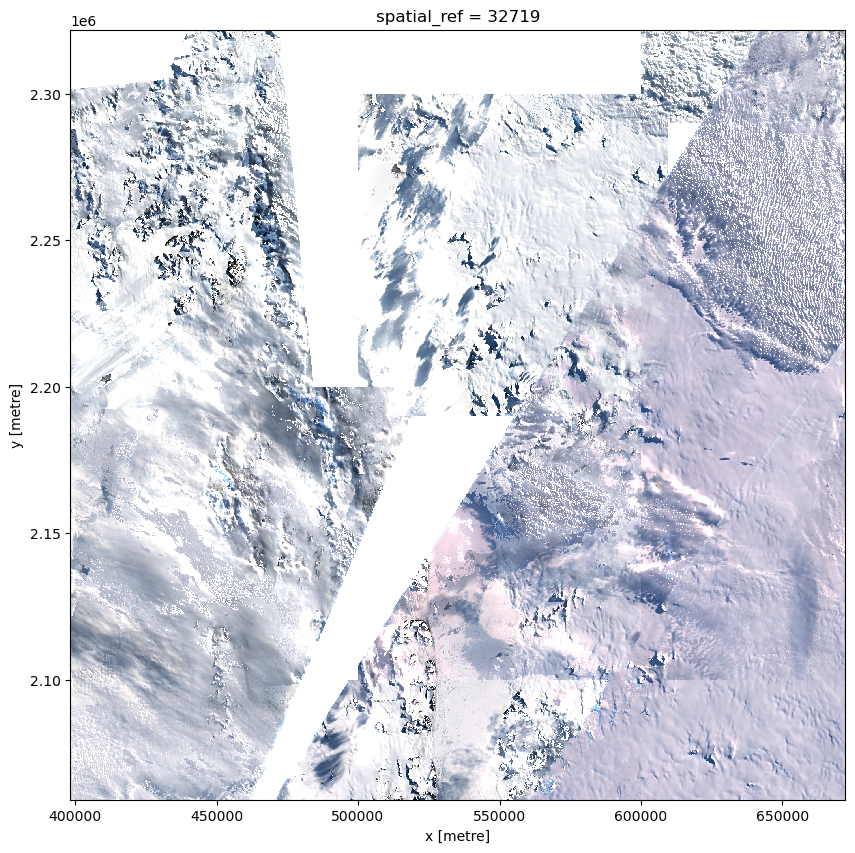

In [ ]:
rgb_median = rgb.median("time", skipna=True)

with ProgressBar():
    rgb_median.to_array("band").plot.imshow(
        x="x",
        y="y",
        rgb="band",
        vmin=0,
        vmax=10000,
        figsize=(10, 10),
    )